In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
import warnings
from scipy import stats
from folium.plugins import HeatMap
import matplotlib.cm as cm
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point  # For plotting maps
import hydroeval as he
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
from scipy.stats import linregress
import statsmodels.api as sm
from scipy.stats import norm

In [2]:
#Read in paired glob, RR, obs dual filtered data and subset relevant columns
glob_RR_obs = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/Clean and filtered RR Glob Obs timeseries.csv', parse_dates = ['dateOffround', 'dateOnround'])
glob_RR_obs = glob_RR_obs[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Modelled_RR', 'Modelled_global', 'Observed','Variable']]

#Convert to long format
dat_all= pd.melt(glob_RR_obs, id_vars = ['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'latitude', 'longitude', 'Variable'], var_name = 'Source')

#Format for timeseries plotting
dat_all['Year'] = dat_all['dateOffround'].dt.year
dat_all['Month'] = dat_all['dateOffround'].dt.month

dat_all_sub = dat_all.loc[((dat_all.Year >= 2017) & (dat_all.Year < 2019)),]
dat_all_sub


,siteId,SamplingInt,dateOnround,dateOffround,latitude,longitude,Variable,Source,value,Year,Month
0,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_SO4_mgm2,Modelled_RR,16.465559,2017,1
1,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_NO3_mgm2,Modelled_RR,30.453215,2017,1
2,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,WetDep_NH4_mgm2,Modelled_RR,3.010674,2017,1
3,AL10,570.0,2017-01-18,2017-01-25,32.4583,-87.2422,Precipitation_mm,Modelled_RR,40.754309,2017,1
4,AL10,572.0,2017-02-01,2017-02-08,32.4583,-87.2422,WetDep_SO4_mgm2,Modelled_RR,7.431907,2017,2
...,...,...,...,...,...,...,...,...,...,...,...
86521,WY08,2.0,2017-05-16,2017-05-23,44.9166,-110.4203,Precipitation_mm,Observed,25.400000,2017,5
86522,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,WetDep_DOC_mgm2,Observed,34.861500,2017,9
86523,WY08,3.0,2017-09-13,2017-09-20,44.9166,-110.4203,Precipitation_mm,Observed,57.150000,2017,9
86524,WY08,4.0,2017-11-14,2017-11-22,44.9166,-110.4203,WetDep_DOC_mgm2,Observed,6.720840,2017,11


In [3]:
#Total monthly average...
dat_all_monyr_sum = dat_all_sub.groupby(['siteId', 'Variable', 'Year', 'Month', 'Source'])['value'].sum().reset_index()
dat_all_monyr = dat_all_monyr_sum.groupby(['Variable', 'Year', 'Month', 'Source'])['value'].mean().reset_index()
dat_all_monyr['Yr-Mon'] = pd.to_datetime(dat_all_monyr[['Year', 'Month']].assign(DAY=1))

#Calculate std error
SE_mod = dat_all_monyr.groupby(['Variable', 'Source'])[['value']].std().reset_index()
SE_mod = SE_mod.rename(columns = {'value' : 'Std'})
dat_all_monyr = pd.merge(dat_all_monyr, SE_mod, on = ['Variable', 'Source'])
dat_all_monyr

,Variable,Year,Month,Source,value,Yr-Mon,Std
0,Precipitation_mm,2017,1,Modelled_RR,62.806571,2017-01-01,24.302885
1,Precipitation_mm,2017,2,Modelled_RR,45.593566,2017-02-01,24.302885
2,Precipitation_mm,2017,3,Modelled_RR,75.995190,2017-03-01,24.302885
3,Precipitation_mm,2017,4,Modelled_RR,91.160279,2017-04-01,24.302885
4,Precipitation_mm,2017,5,Modelled_RR,124.971244,2017-05-01,24.302885
...,...,...,...,...,...,...,...
175,WetDep_SO4_mgm2,2017,8,Observed,27.084965,2017-08-01,9.067188
176,WetDep_SO4_mgm2,2017,9,Observed,19.532366,2017-09-01,9.067188
177,WetDep_SO4_mgm2,2017,10,Observed,16.789627,2017-10-01,9.067188
178,WetDep_SO4_mgm2,2017,11,Observed,26.484742,2017-11-01,9.067188


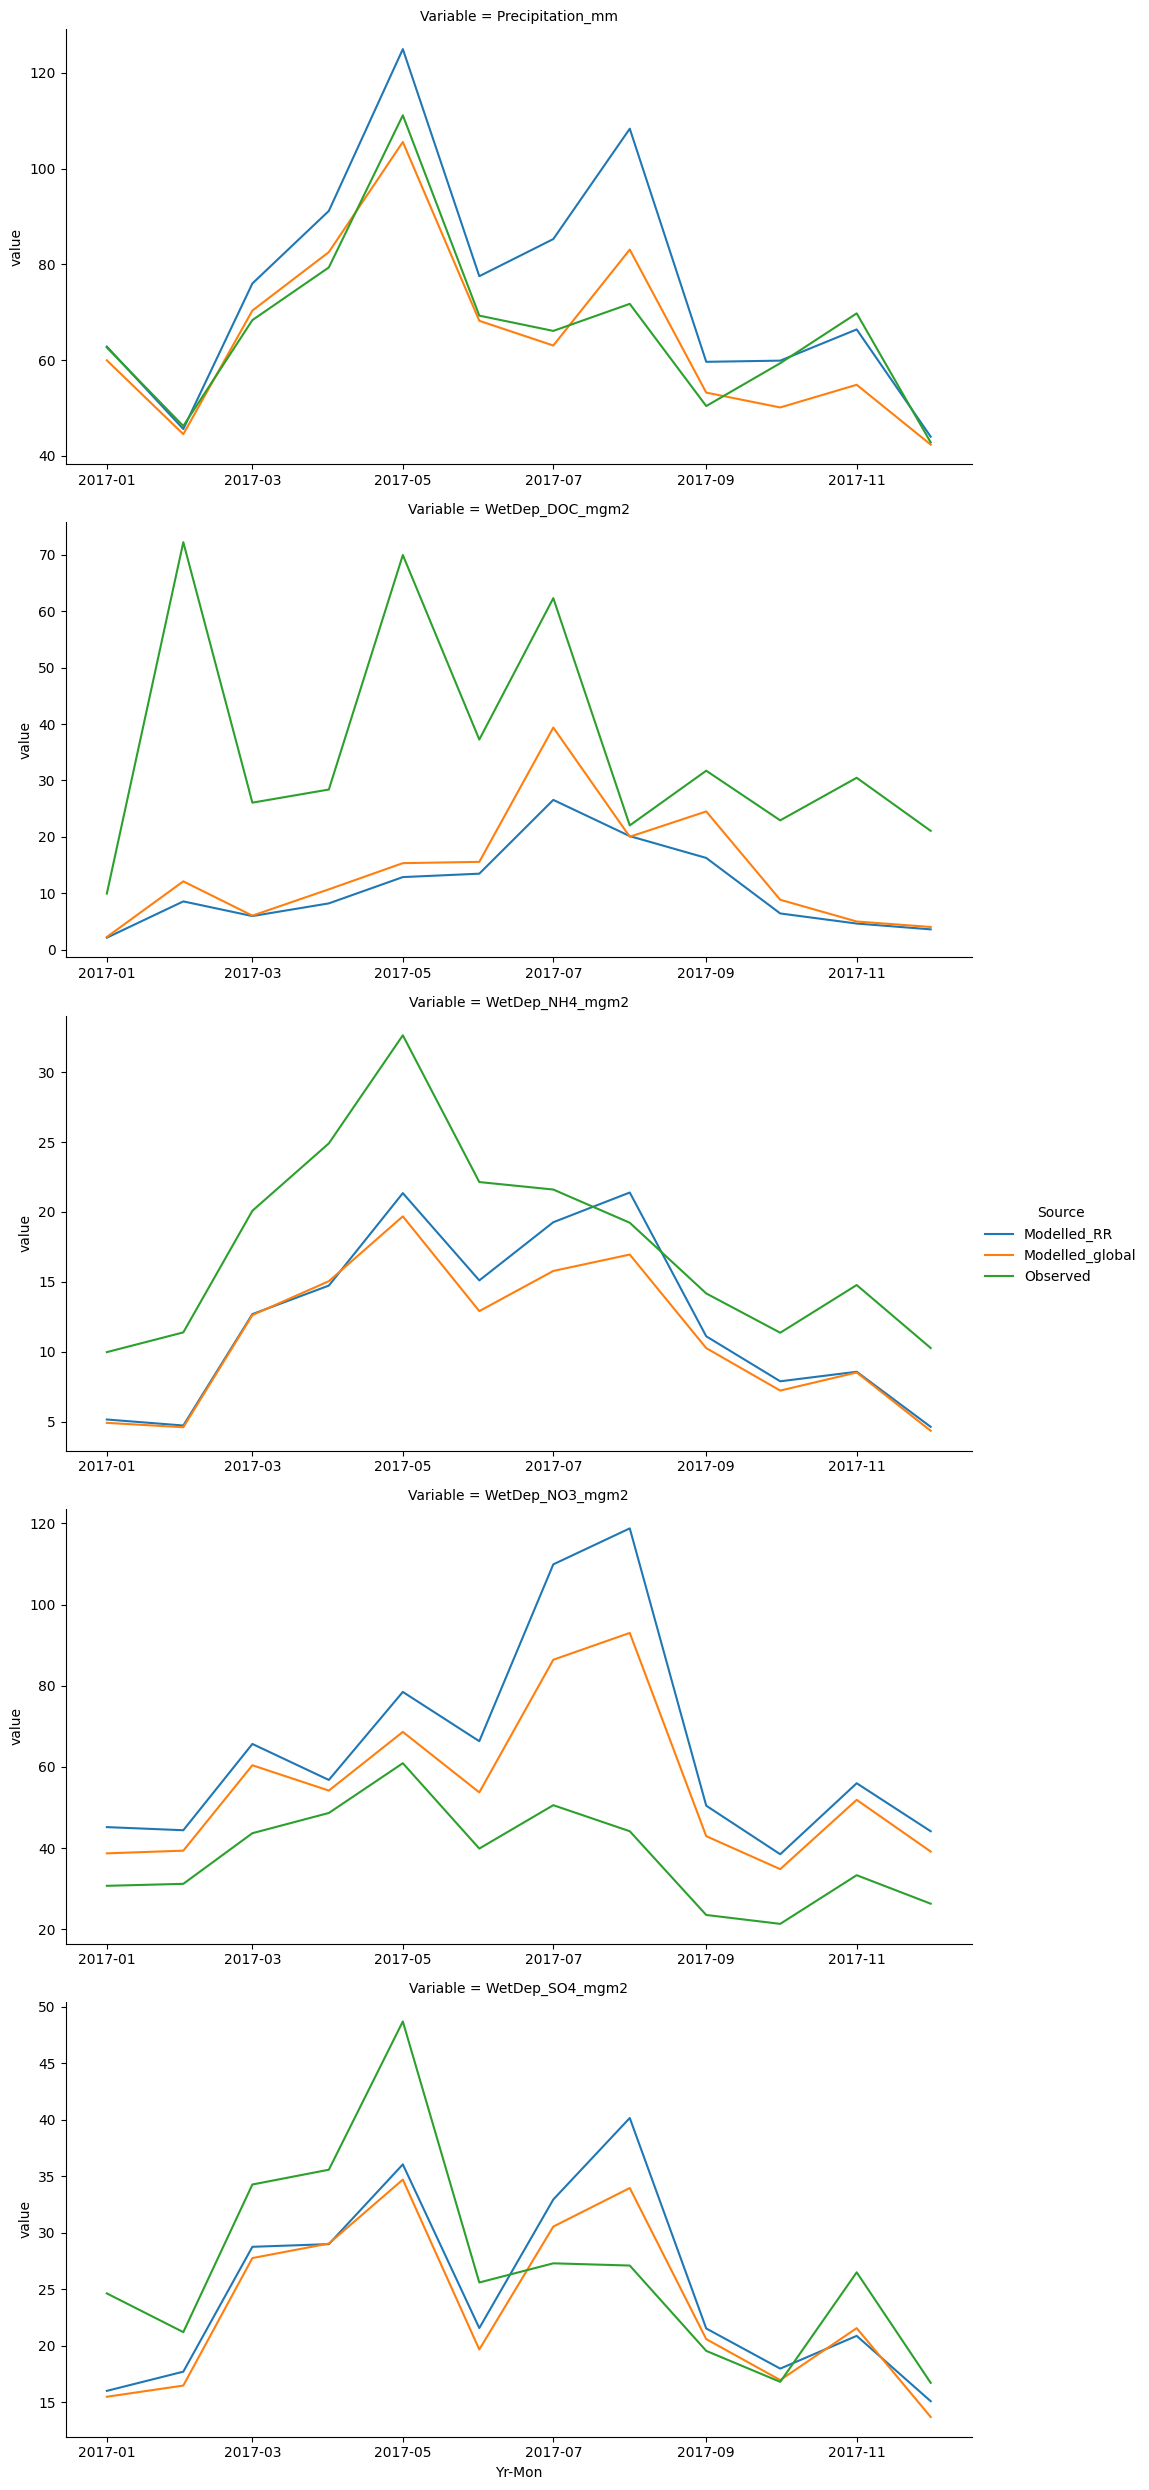

In [4]:
sns.relplot(
    data=dat_all_monyr, x="Yr-Mon", y="value",
    col="Variable", hue="Source", kind="line", col_wrap=1,
    facet_kws={'sharey': False, 'sharex' : False},  # Allow different y-axis bounds for each facet
    height=5, aspect=2,  # Increase height and width
)


In [5]:
# Plot timeseries

# Assuming 'dat_all_monyr' is your DataFrame and 'Yr-Mon' is in datetime format
for i in dat_all_monyr['Variable'].unique():
    dat_sub = dat_all_monyr.loc[dat_all_monyr['Variable'] == i]

    # Ensure 'Yr-Mon' is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(dat_sub['Yr-Mon']):
        dat_sub['Yr-Mon'] = pd.to_datetime(dat_sub['Yr-Mon'])

    # Set 'Yr-Mon' as the index for time-based regression
    dat_sub.set_index('Yr-Mon', inplace=True)

    # Add a constant term for intercept
    X_modelled = sm.add_constant(dat_sub.index.astype('int64') // 10**9)  # Convert datetime to Unix timestamp
    y_modelled = dat_sub['Modelled']
    
    X_observed = sm.add_constant(dat_sub.index.astype('int64') // 10**9)  # Convert datetime to Unix timestamp
    y_observed = dat_sub['Observed']

    # Fit the models
    model_modelled = sm.OLS(y_modelled, X_modelled).fit()
    model_observed = sm.OLS(y_observed, X_observed).fit()

    # Create the regression plot
    plt.figure(figsize=(14, 6))
    #sns.set_theme(style="ticks", palette=None)
    
    sns.regplot(x=dat_sub.index.astype('int64') // 10**9, y='Modelled', data=dat_sub, lowess=False, ci=True, color='goldenrod', label='Modelled')
    sns.regplot(x=dat_sub.index.astype('int64') // 10**9, y='Observed', data=dat_sub, lowess=False, ci=True, color='cornflowerblue', label='Observed')
    
    plt.plot(dat_sub.index.astype('int64') // 10**9, dat_sub.Modelled, color='goldenrod', alpha=0.5)
    plt.fill_between(dat_sub.index.astype('int64') // 10**9, dat_sub.Modelled-dat_sub['Mod_SE'], dat_sub.Modelled+dat_sub['Mod_SE'], alpha=0.1, edgecolor='goldenrod', facecolor='goldenrod')
    plt.plot(dat_sub.index.astype('int64') // 10**9, dat_sub.Observed, color='cornflowerblue', alpha=0.5)
    plt.fill_between(dat_sub.index.astype('int64') // 10**9, dat_sub.Observed-dat_sub['Obs_SE'], dat_sub.Observed+dat_sub['Obs_SE'], alpha=0.1, edgecolor='cornflowerblue', facecolor='cornflowerblue')

    plt.xlabel("")
    plt.ylabel(i)
    #plt.xlim(dat_sub.index.astype('int64').min() // 10**9, dat_sub.index.astype('int64').max() // 10**9)
    plt.legend(loc='upper right')
    plt.title(f'Global: {i}')
    #plt.ylim(-10,52)
    #plt.gca().set_ylim(bottom=0)

    ax = plt.gca()
    new_labels = pd.to_datetime(ax.get_xticks() * 10**9)
    ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)

    #plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/Monthly Timeseries Mod Obs {i}.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

    plt.show()

KeyError: 'Modelled'

In [ ]:
# Do the same for MUSICA timeseries:
dat_all_mus = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/MUSICA Cleaned Paired Modeled Observed Timeseries.csv', 
                      parse_dates = ['dateOnround', 'dateOffround'])
dat_all_mus['Year'] = dat_all_mus['dateOffround'].dt.year
dat_all_mus = dat_all_mus.loc[((dat_all_mus.Year >= 2017) & (dat_all_mus.Year < 2019)),]
dat_all_mus

#Total monthly average...
dat_mus_monyr_sum = dat_all_mus.groupby(['siteId', 'Variable', 'Year', 'Month'])['Modelled', 'Observed'].sum().reset_index()
dat_mus_monyr = dat_mus_monyr_sum.groupby(['Variable', 'Year', 'Month'])['Modelled', 'Observed'].mean().reset_index()
dat_mus_monyr['Yr-Mon'] = pd.to_datetime(dat_mus_monyr[['Year', 'Month']].assign(DAY=1))
dat_mus_monyr

#Calculate std error
SE_mod = dat_mus_monyr.groupby('Variable')[['Modelled', 'Observed']].std().reset_index()
SE_mod = SE_mod.rename(columns = {'Modelled' : 'Mod_SE', 'Observed' : 'Obs_SE'})
dat_mus_monyr = pd.merge(dat_mus_monyr, SE_mod, on = 'Variable')
dat_mus_monyr

In [ ]:
# Plot timeseries

# Assuming 'dat_all_monyr' is your DataFrame and 'Yr-Mon' is in datetime format
for i in dat_mus_monyr['Variable'].unique():
    dat_sub = dat_mus_monyr.loc[dat_mus_monyr['Variable'] == i]

    # Ensure 'Yr-Mon' is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(dat_sub['Yr-Mon']):
        dat_sub['Yr-Mon'] = pd.to_datetime(dat_sub['Yr-Mon'])

    # Set 'Yr-Mon' as the index for time-based regression
    dat_sub.set_index('Yr-Mon', inplace=True)

    # Add a constant term for intercept
    X_modelled = sm.add_constant(dat_sub.index.astype('int64') // 10**9)  # Convert datetime to Unix timestamp
    y_modelled = dat_sub['Modelled']
    
    X_observed = sm.add_constant(dat_sub.index.astype('int64') // 10**9)  # Convert datetime to Unix timestamp
    y_observed = dat_sub['Observed']

    # Fit the models
    model_modelled = sm.OLS(y_modelled, X_modelled).fit()
    model_observed = sm.OLS(y_observed, X_observed).fit()

    # Create the regression plot
    plt.figure(figsize=(14, 6))
    #sns.set_theme(style="ticks", palette=None)
    
    sns.regplot(x=dat_sub.index.astype('int64') // 10**9, y='Modelled', data=dat_sub, lowess=False, ci=True, color='goldenrod', label='Modelled')
    sns.regplot(x=dat_sub.index.astype('int64') // 10**9, y='Observed', data=dat_sub, lowess=False, ci=True, color='cornflowerblue', label='Observed')
    
    plt.plot(dat_sub.index.astype('int64') // 10**9, dat_sub.Modelled, color='goldenrod', alpha=0.5)
    plt.fill_between(dat_sub.index.astype('int64') // 10**9, dat_sub.Modelled-dat_sub['Mod_SE'], dat_sub.Modelled+dat_sub['Mod_SE'], alpha=0.1, edgecolor='goldenrod', facecolor='goldenrod')
    plt.plot(dat_sub.index.astype('int64') // 10**9, dat_sub.Observed, color='cornflowerblue', alpha=0.5)
    plt.fill_between(dat_sub.index.astype('int64') // 10**9, dat_sub.Observed-dat_sub['Obs_SE'], dat_sub.Observed+dat_sub['Obs_SE'], alpha=0.1, edgecolor='cornflowerblue', facecolor='cornflowerblue')

    plt.xlabel("")
    plt.ylabel(i)
    #plt.xlim(dat_sub.index.astype('int64').min() // 10**9, dat_sub.index.astype('int64').max() // 10**9)
    plt.legend(loc='upper right')
    plt.title(f'MUSICA: {i}')
    plt.ylim(-10,58)
    #plt.gca().set_ylim(bottom=0)

    ax = plt.gca()
    new_labels = pd.to_datetime(ax.get_xticks() * 10**9)
    ax.set_xticklabels(new_labels.strftime('%Y-%m-%d'))#, rotation=45)

    #plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/Monthly Timeseries Mod Obs {i}.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

    plt.show()